Spaceship Titanic

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# Looking at the data first
raw_data = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Spaceship Titanic\train.csv")
print(raw_data.shape)
raw_data.head(10)

(8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


---------------Exploratory Data Analysis (EDA)---------------

In [4]:
# Checking missing values
def missing_values_table(df) :
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100*df.isnull().sum() / len(df)

    # Make a table with results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis = 1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns ={0:'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,1]!=0].sort_values('% of Total Values', ascending = False).round(1)

    # Print some summary information
    print('Your selected dataframe has ' + str(df.shape[1]) + ' columns.\n'
          'There are ' + str(mis_val_table_ren_columns.shape[0]) + ' columns that have missing values !')

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

missing_values_table(raw_data)

Your selected dataframe has 14 columns.
There are 12 columns that have missing values !


,Missing Values,% of Total Values
CryoSleep,217,2.5
ShoppingMall,208,2.4
VIP,203,2.3
HomePlanet,201,2.3
Name,200,2.3
Cabin,199,2.3
VRDeck,188,2.2
FoodCourt,183,2.1
Spa,183,2.1
Destination,182,2.1


In [5]:
# Checking duplicates
raw_data.duplicated().sum()

np.int64(0)

In [6]:
raw_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


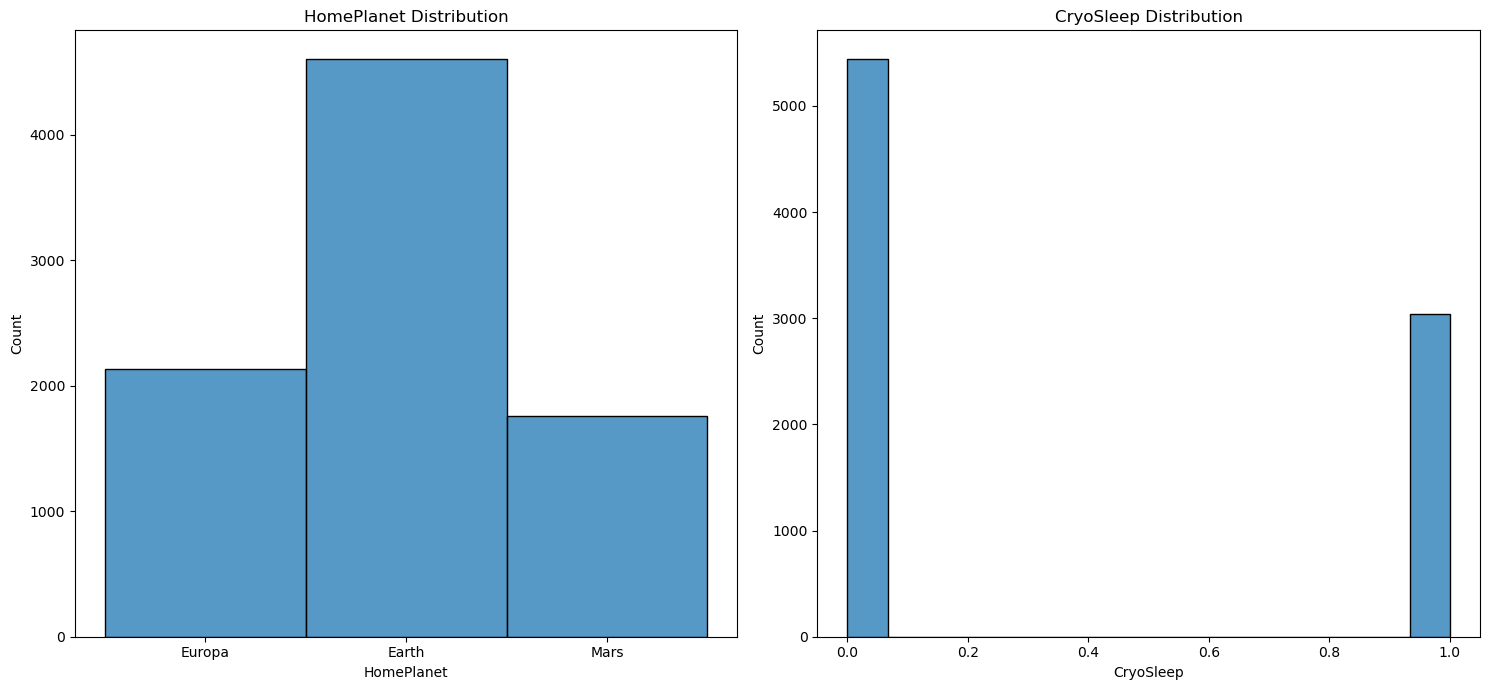

In [7]:
# EDA of HommePlanet and Cryosleep
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize =(15,7))

sns.histplot(raw_data['HomePlanet'], ax=axes[0])
axes[0].set_title('HomePlanet Distribution')

sns.histplot(raw_data['CryoSleep'], ax=axes[1])
axes[1].set_title('CryoSleep Distribution')

plt.tight_layout()
plt.show()

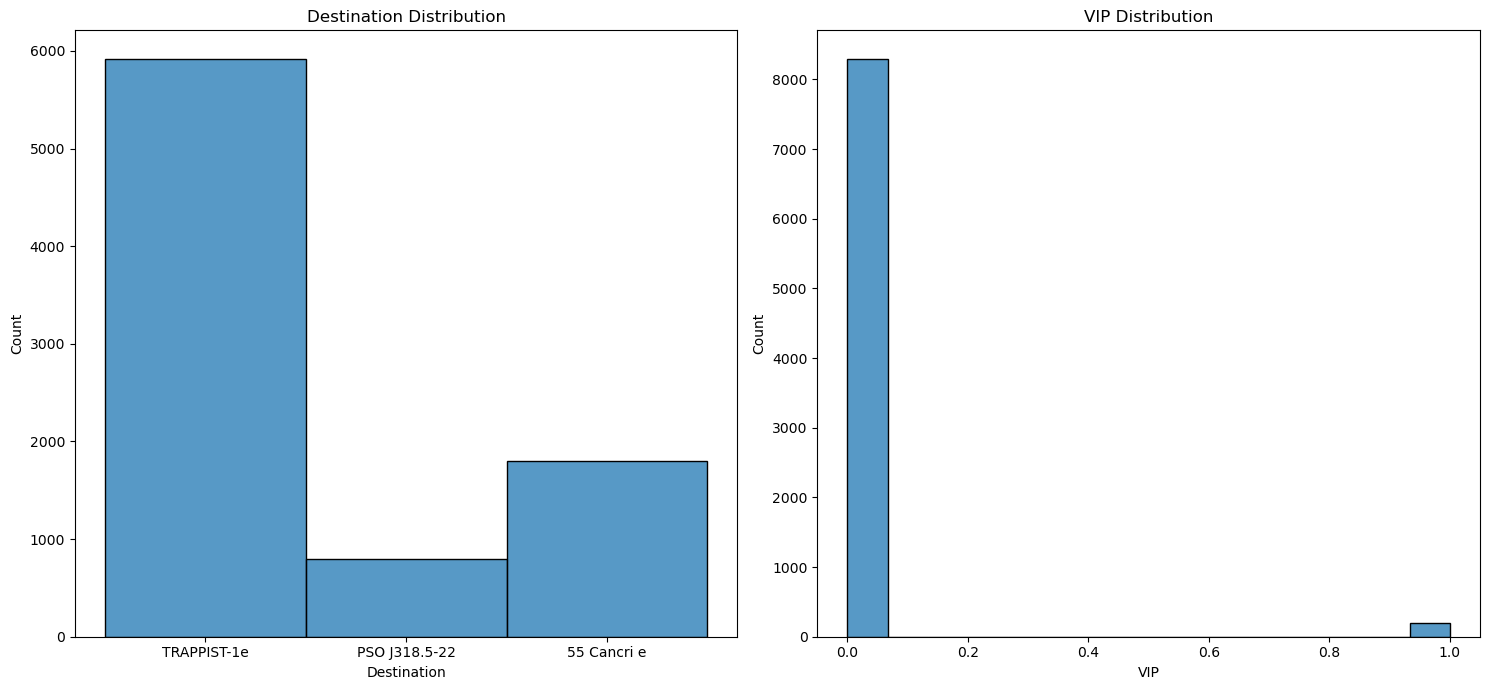

In [8]:
# EDA of Destination and VIP
fig2, axes2 = plt.subplots(1, 2, figsize =(15,7))
sns.histplot(raw_data['Destination'], ax=axes2[0])
axes2[0].set_title('Destination Distribution')

sns.histplot(raw_data['VIP'], ax=axes2[1])
axes2[1].set_title('VIP Distribution')

plt.tight_layout()
plt.show()

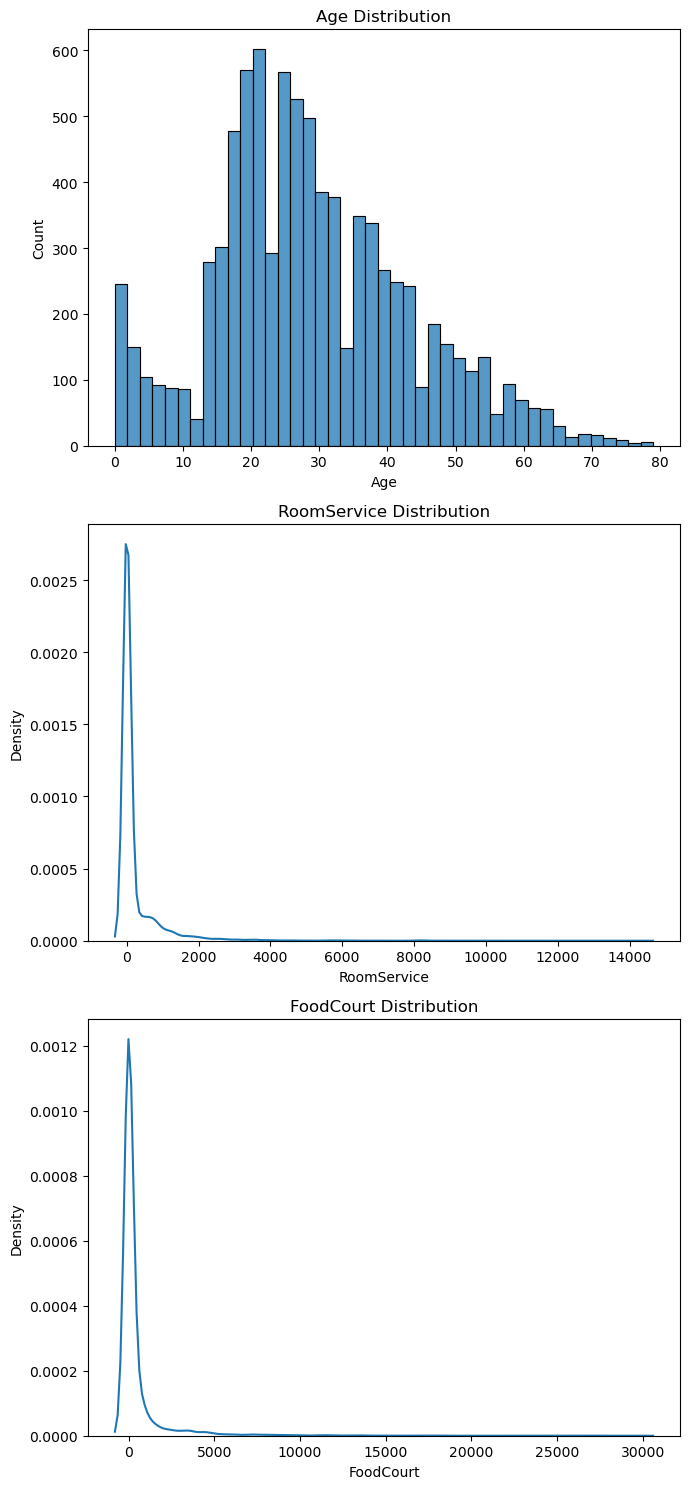

In [9]:
# EDA of the Age, the RoomService and the FoodCourt columns
fig3, axes3 = plt.subplots(3, 1, figsize =(7,15))
sns.histplot(raw_data['Age'], ax=axes3[0])
axes3[0].set_title('Age Distribution')

sns.kdeplot(raw_data['RoomService'], ax=axes3[1])
axes3[1].set_title('RoomService Distribution')

sns.kdeplot(raw_data['FoodCourt'], ax=axes3[2])
axes3[2].set_title('FoodCourt Distribution')

plt.tight_layout()
plt.show()

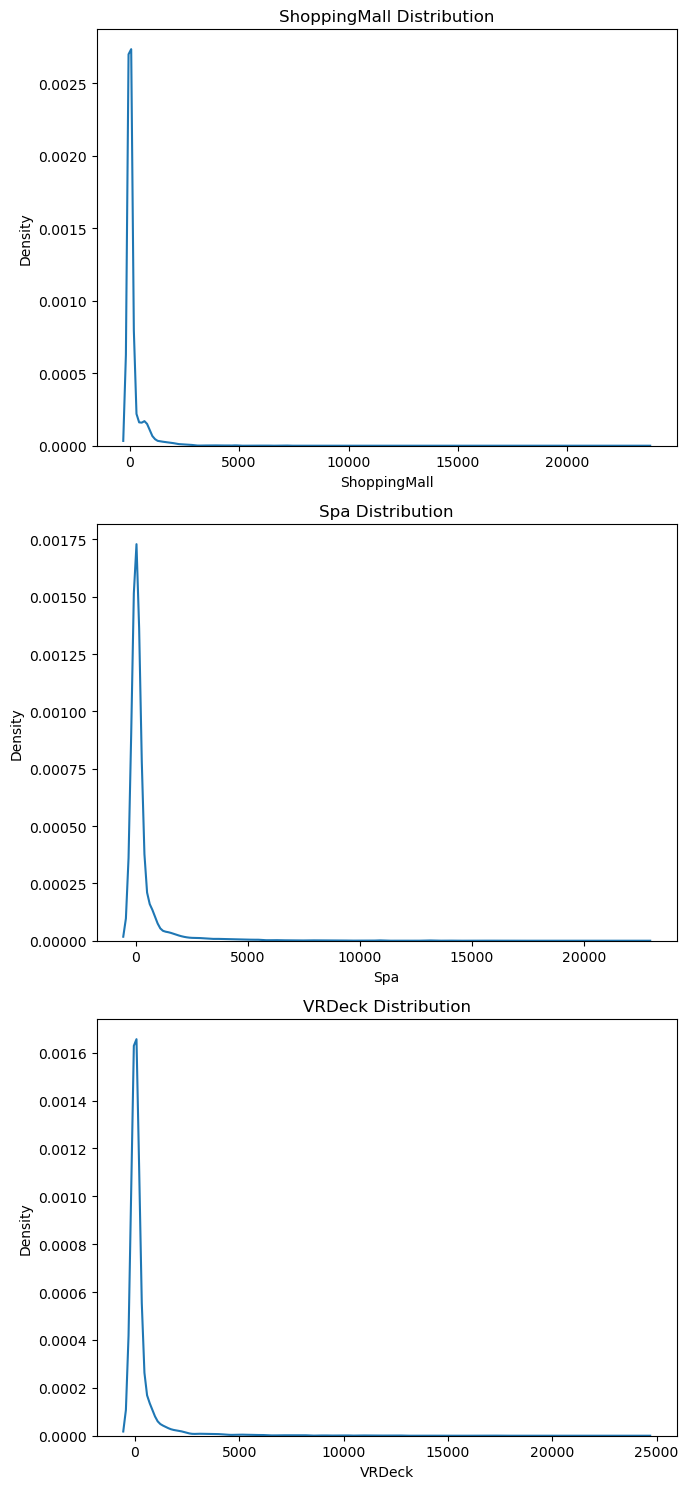

In [10]:
# EDA of ShoppingMall, Spa and VRDeck
fig4, axes4 = plt.subplots(3, 1, figsize =(7,15))
sns.kdeplot(raw_data['ShoppingMall'], ax=axes4[0])
axes4[0].set_title('ShoppingMall Distribution')

sns.kdeplot(raw_data['Spa'], ax=axes4[1])
axes4[1].set_title('Spa Distribution')

sns.kdeplot(raw_data['VRDeck'], ax=axes4[2])
axes4[2].set_title('VRDeck Distribution')

plt.tight_layout()
plt.show()

In [11]:
raw_data['Cabin'].nunique()

6560

In [12]:
# The column 'Cabin' has a lot of variables so we need to split it before starting preprocessing

In [13]:
# Splitting 'Cabin' into 'Deck', 'Num' and 'Side'
raw_data[['Deck', 'Num', 'Side']] = raw_data['Cabin'].str.split('/', expand = True)
raw_data['Num'] = pd.to_numeric(raw_data['Num'])
raw_data = raw_data.drop('Cabin', axis = 1)
raw_data.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S


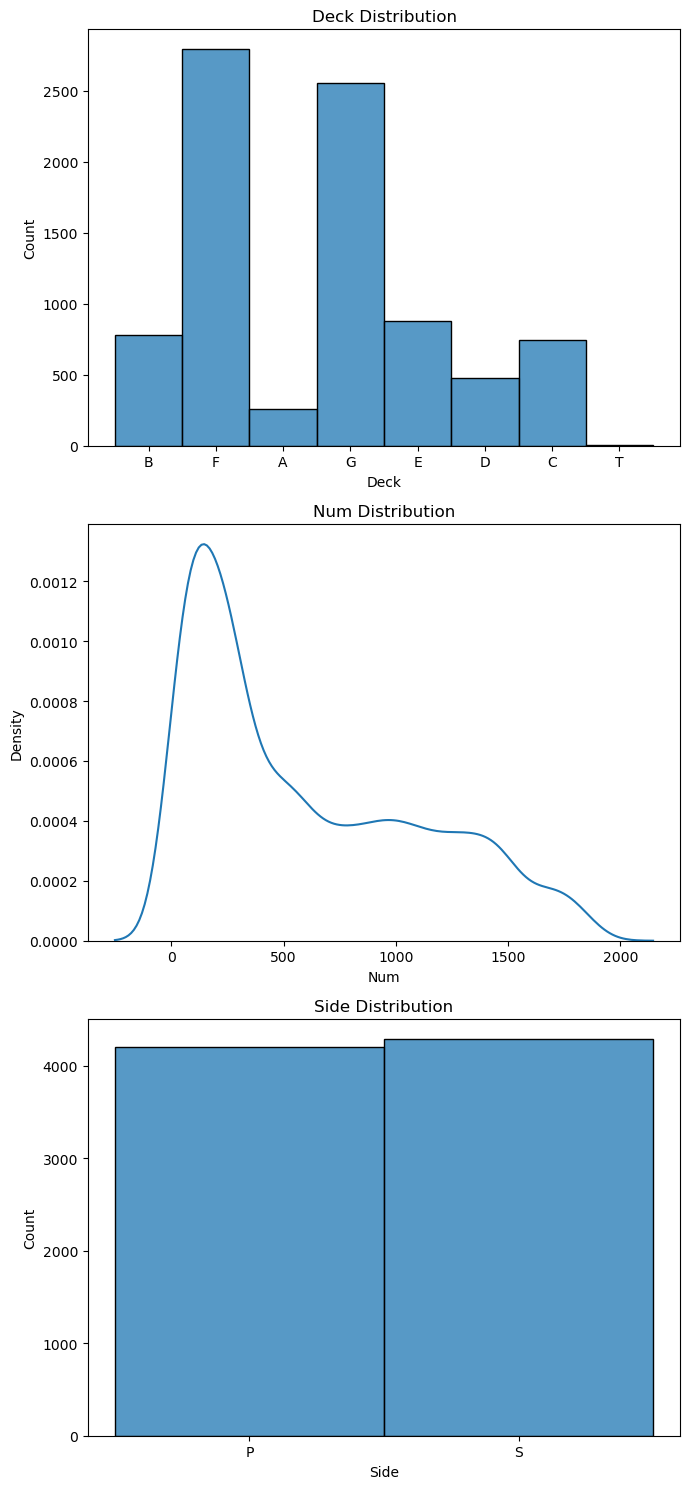

In [14]:
# EDA of Deck, Num and Side
fig5, axes5 = plt.subplots(3, 1, figsize =(7,15))
sns.histplot(raw_data['Deck'], ax=axes5[0])
axes5[0].set_title('Deck Distribution')

sns.kdeplot(raw_data['Num'], ax=axes5[1])
axes5[1].set_title('Num Distribution')

sns.histplot(raw_data['Side'], ax=axes5[2])
axes5[2].set_title('Side Distribution')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation')

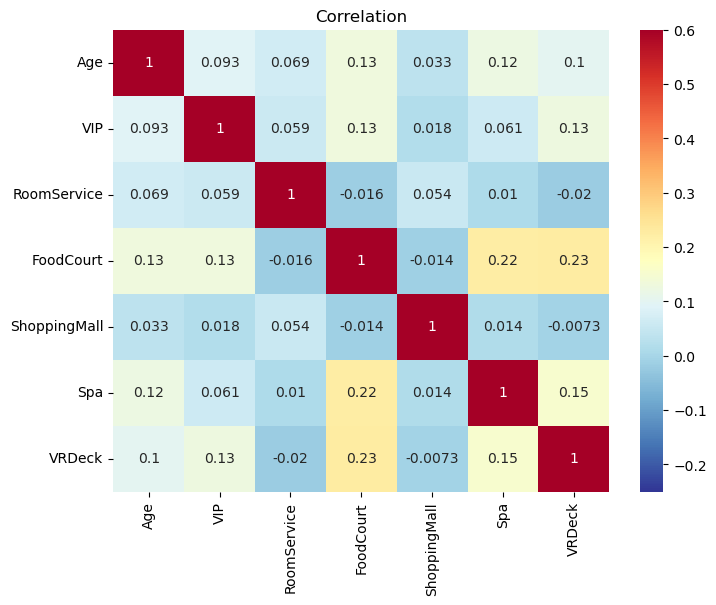

In [15]:
# Just for curiosity
data_col = raw_data[['Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']]
corr_data_col = data_col.corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr_data_col, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation')

Results of the EDA :
    All the columns have missing values besides PassengerId and Transported.
    Some columns are pretty normal (normal distribution) but others are filled with 0. We can easily assume that we can replace their missing values with 0 using fillna(0).
    A SimpleImputer with a strategy = most_frequent for the missing values of categorical columns and strategy = median for the numerical one.
    The numerical columns aren't heavily correlated, so no problem of data leakage during the fit for the model.

---------------EDA End---------------

---------------Preprocess and training model---------------

In [16]:
# Getting more information for the training by taking the first part of the PassengerId
raw_data['Group'] = raw_data['PassengerId'].str.split('_').str[0]
group_size = raw_data.groupby('Group')['Group'].transform('count')
raw_data['GroupSize'] = group_size
raw_data['IsAlone'] = (raw_data['GroupSize'] == 1).astype(int)

raw_data.head(10)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,Group,GroupSize,IsAlone
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0001,1,1
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,0002,1,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,0003,2,0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,0003,2,0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,0004,1,1
5,0005_01,Earth,False,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,F,0.0,P,0005,1,1
6,0006_01,Earth,False,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0
7,0006_02,Earth,True,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,G,0.0,S,0006,2,0
8,0007_01,Earth,False,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,F,3.0,S,0007,1,1
9,0008_01,Europa,True,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,B,1.0,P,0008,3,0


In [17]:
# Start of the proprecess
data = raw_data.copy()
data = data.drop(columns = ['PassengerId', 'Name'])
data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,Group,GroupSize,IsAlone
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,0001,1,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,0002,1,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,0003,2,0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,0003,2,0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,0004,1,1


In [18]:
# Features and target
X = data.drop(columns = 'Transported')
y = data.Transported

In [19]:
# The split
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state = 0)

In [20]:
# Separating categorical and numerical columns
categorical_col = [cname for cname in X_train.columns if X_train[cname].dtypes == 'object']
numerical_col = [cname for cname in X_train.columns if X_train[cname].dtypes in ['int64', 'float64']]
numerical_col = [b for b in numerical_col if b not in ['GroupSize', 'IsAlone']]

# Saving this two for the final
size_alone_train = X_train[['GroupSize', 'IsAlone']]
size_alone_val = X_val[['GroupSize', 'IsAlone']]

c = (X_train.dtypes == 'object')
object_cols = list(c[c].index)
object_cols = [c for c in object_cols if c != 'Group'] # Removing Group due to data leakage risk

In [21]:
object_cols

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

In [22]:
print('CATEGORICAL COLUMNS : ' + str(categorical_col))
print('NUMERICAL COUMNS : ' + str(numerical_col) )

CATEGORICAL COLUMNS : ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Group']
NUMERICAL COUMNS : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num']


In [23]:
raw_data.head(10)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,Group,GroupSize,IsAlone
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0001,1,1
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,0002,1,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,0003,2,0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,0003,2,0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,0004,1,1
5,0005_01,Earth,False,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,F,0.0,P,0005,1,1
6,0006_01,Earth,False,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0
7,0006_02,Earth,True,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,G,0.0,S,0006,2,0
8,0007_01,Earth,False,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,F,3.0,S,0007,1,1
9,0008_01,Europa,True,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,B,1.0,P,0008,3,0


In [24]:
# Dealing with missing values for categorical columns
X_train[object_cols] = X_train.groupby('Group')[object_cols].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
) # Training data, turning 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck' missing values into 0

X_val[object_cols] = X_val.groupby('Group')[object_cols].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
) # Validation data, turning 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck' missing values into 0

X_train = X_train.drop(columns = ('Group'))
X_val = X_val.drop(columns = ('Group'))

# The transformation pipeline written by hand first to see any bugs
cat_imputer = SimpleImputer(strategy = 'most_frequent')
X_train_imputed = pd.DataFrame(cat_imputer.fit_transform(X_train[object_cols]))
X_val_imputed = pd.DataFrame(cat_imputer.transform(X_val[object_cols]))

X_train_imputed.columns = X_train[object_cols].columns
X_val_imputed.columns = X_val[object_cols].columns

C:\Users\Lazasoa\AppData\Local\Temp\ipykernel_18968\2035214154.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
C:\Users\Lazasoa\AppData\Local\Temp\ipykernel_18968\2035214154.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x


In [25]:
X_train_imputed.head()

,HomePlanet,CryoSleep,Destination,VIP,Deck,Side
0,Mars,True,TRAPPIST-1e,False,F,P
1,Earth,False,55 Cancri e,False,G,S
2,Earth,False,PSO J318.5-22,False,F,S
3,Earth,False,55 Cancri e,False,G,P
4,Mars,False,TRAPPIST-1e,False,F,S


In [26]:
X_train_imputed.isnull().sum()

HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
Deck           0
Side           0
dtype: int64

In [27]:
X_val_imputed.head()

,HomePlanet,CryoSleep,Destination,VIP,Deck,Side
0,Earth,False,55 Cancri e,False,F,S
1,Earth,False,55 Cancri e,False,G,S
2,Earth,False,TRAPPIST-1e,False,G,S
3,Earth,False,55 Cancri e,False,F,P
4,Europa,True,55 Cancri e,True,B,P


In [28]:
X_val_imputed.isnull().sum()

HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
Deck           0
Side           0
dtype: int64

In [29]:
# No missing value left for categorical columns

In [30]:
# Dealing missing values for numerical columns
# For Num and Age columns
num_imputer = SimpleImputer(strategy = 'median')
num_age_train = pd.DataFrame(num_imputer.fit_transform(pd.DataFrame(X_train[['Num', 'Age']])))
num_age_val = pd.DataFrame(num_imputer.transform(pd.DataFrame(X_val[['Num', 'Age']])))

num_age_train.columns = pd.DataFrame(X_train[['Num', 'Age']]).columns
num_age_val.columns = pd.DataFrame(X_val[['Num', 'Age']]).columns

num_age_train.index = X_train.index
num_age_val.index = X_val.index

# For the rest of numerical columns
other_num_cols_train = X_train[numerical_col].drop(columns = ['Num', 'Age'])
other_num_cols_train.fillna(0, inplace = True)

other_num_cols_val = X_val[numerical_col].drop(columns = ['Num', 'Age'])
other_num_cols_val.fillna(0, inplace = True)

In [31]:
num_age_train.head()

,Num,Age
5020,1102.0,37.0
5967,1025.0,44.0
991,199.0,27.0
2894,512.0,15.0
2228,461.0,23.0


In [32]:
num_age_train.isnull().sum()

Num    0
Age    0
dtype: int64

In [33]:
num_age_val.head()

,Num,Age
3601,731.0,16.0
6057,424.0,2.0
2797,476.0,31.0
7110,1572.0,14.0
8579,298.0,30.0


In [34]:
num_age_val.isnull().sum()

Num    0
Age    0
dtype: int64

In [35]:
other_num_cols_train.head()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
5020,0.0,0.0,0.0,0.0,0.0
5967,0.0,0.0,0.0,0.0,0.0
991,182.0,0.0,0.0,0.0,376.0
2894,62.0,57.0,2646.0,1104.0,312.0
2228,1773.0,0.0,78.0,0.0,3.0


In [36]:
other_num_cols_train.isnull().sum()

RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [37]:
other_num_cols_val.head()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
3601,0.0,0.0,623.0,40.0,209.0
6057,0.0,0.0,0.0,0.0,0.0
2797,517.0,1.0,301.0,60.0,4.0
7110,653.0,0.0,4.0,0.0,0.0
8579,0.0,0.0,0.0,0.0,0.0


In [38]:
other_num_cols_val.isnull().sum()

RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [39]:
# No missing value left for numerical columns

In [40]:
# Encoding categorical columns
OH_encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train_imputed))
OH_cols_val = pd.DataFrame(OH_encoder.transform(X_val_imputed))

OH_cols_train.index = X_train.index
OH_cols_val.index = X_val.index

In [41]:
OH_cols_train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
5020,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5967,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
991,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2894,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2228,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4373,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7891,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4859,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3264,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [42]:
OH_cols_val

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
3601,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6057,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2797,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
7110,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8579,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1856,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4160,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6477,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3641,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [43]:
# Verification if everything is done wrong
# Verification n°1
for col, cats in zip(object_cols, OH_encoder.categories_):
    print(col, "->", len(cats), "categories")

HomePlanet -> 3 categories
CryoSleep -> 2 categories
Destination -> 3 categories
VIP -> 2 categories
Deck -> 8 categories
Side -> 2 categories


In [44]:
# List of categorical variable encoded
# Verification n°2
object_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]
somme = sum(X_train[col].nunique() for col in object_cols)
print(somme)

20


In [45]:
# Then finally, we merge everything together
X_train_plus = pd.concat([num_age_train, other_num_cols_train, OH_cols_train, size_alone_train], axis = 1)
X_val_plus = pd.concat([num_age_val, other_num_cols_val, OH_cols_val, size_alone_val], axis = 1)

In [46]:
X_train_plus.head()

,Num,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,0,1,2,...,12,13,14,15,16,17,18,19,GroupSize,IsAlone
5020,1102.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1
5967,1025.0,44.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3,0
991,199.0,27.0,182.0,0.0,0.0,0.0,376.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1
2894,512.0,15.0,62.0,57.0,2646.0,1104.0,312.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1
2228,461.0,23.0,1773.0,0.0,78.0,0.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1


In [47]:
X_val_plus.head()

,Num,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,0,1,2,...,12,13,14,15,16,17,18,19,GroupSize,IsAlone
3601,731.0,16.0,0.0,0.0,623.0,40.0,209.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7,0
6057,424.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4,0
2797,476.0,31.0,517.0,1.0,301.0,60.0,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2,0
7110,1572.0,14.0,653.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1
8579,298.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1


In [48]:
# Turning every columns into String otherwise the model will grumble
X_train_plus.columns = X_train_plus.columns.astype(str)
X_val_plus.columns = X_val_plus.columns.astype(str)

n_estimators=50 -> mean accuracy=0.7882 (+/- 0.0066)
n_estimators=100 -> mean accuracy=0.7911 (+/- 0.0072)
n_estimators=150 -> mean accuracy=0.7949 (+/- 0.0085)
n_estimators=200 -> mean accuracy=0.7952 (+/- 0.0083)
n_estimators=250 -> mean accuracy=0.7952 (+/- 0.0065)
n_estimators=300 -> mean accuracy=0.7957 (+/- 0.0073)
n_estimators=350 -> mean accuracy=0.7951 (+/- 0.0062)
n_estimators=400 -> mean accuracy=0.7957 (+/- 0.0078)


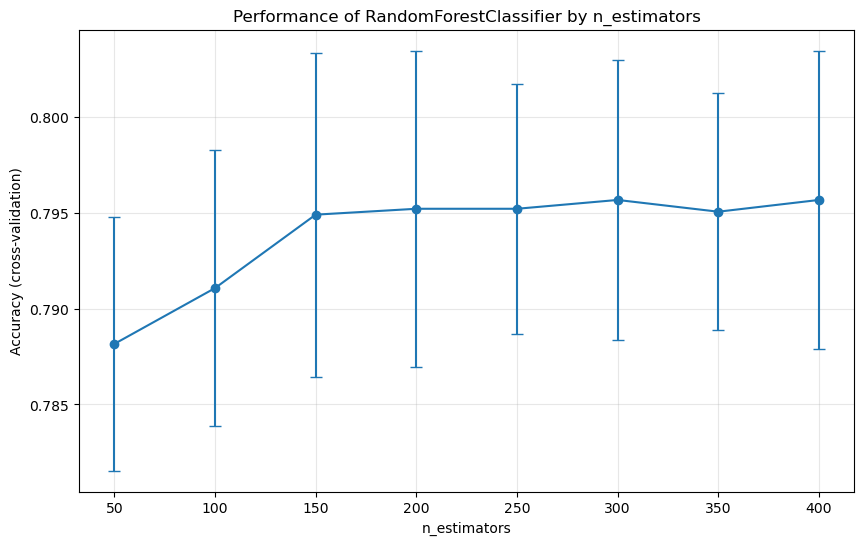


Best n_estimators : 400 with accuracy=0.7957


In [49]:
# Testing with cross_val_score which n_estimators is the best with RandomForest
n_estimators_list = [50, 100, 150, 200, 250, 300, 350, 400]
mean_scores = []
std_scores = []

for n in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n, random_state=0)
    scores = cross_val_score(model, X_train_plus, y_train, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    print(f"n_estimators={n} -> mean accuracy={scores.mean():.4f} (+/- {scores.std():.4f})")

# Chart
plt.figure(figsize=(10, 6))
plt.errorbar(n_estimators_list, mean_scores, yerr=std_scores, marker='o', capsize=4)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy (cross-validation)")
plt.title("Performance of RandomForestClassifier by n_estimators")
plt.grid(True, alpha=0.3)
plt.show()

# Best n_estimators
best_idx = mean_scores.index(max(mean_scores))
print(f"\nBest n_estimators : {n_estimators_list[best_idx]} with accuracy={mean_scores[best_idx]:.4f}")

n_estimators=50 -> mean accuracy=0.7952 (+/- 0.0133)
n_estimators=100 -> mean accuracy=0.7992 (+/- 0.0112)
n_estimators=150 -> mean accuracy=0.8043 (+/- 0.0110)
n_estimators=200 -> mean accuracy=0.8041 (+/- 0.0073)
n_estimators=250 -> mean accuracy=0.8044 (+/- 0.0079)
n_estimators=300 -> mean accuracy=0.8058 (+/- 0.0079)
n_estimators=350 -> mean accuracy=0.8046 (+/- 0.0084)
n_estimators=400 -> mean accuracy=0.8049 (+/- 0.0071)


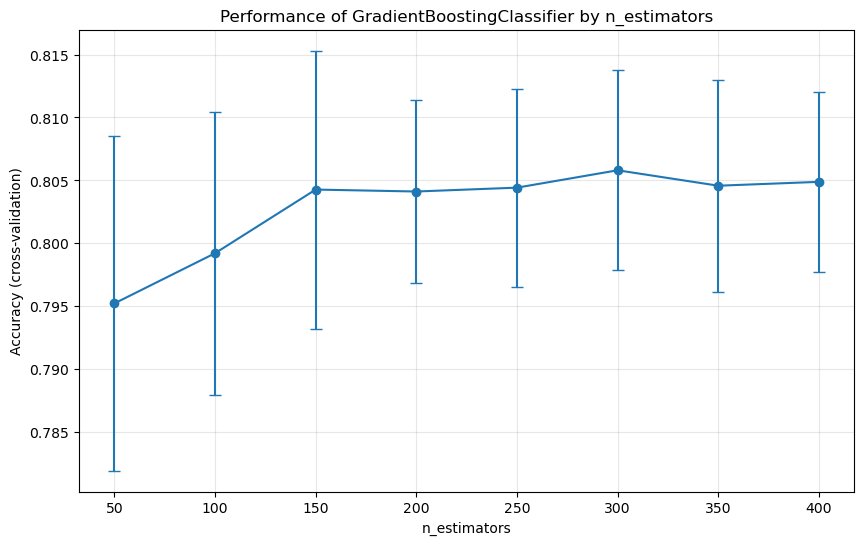


Best n_estimators : 300 with accuracy=0.8058


In [50]:
# Testing with cross_val_score which n_estimators is the best with GradientBoosting
n_estimators_list2 = [50, 100, 150, 200, 250, 300, 350, 400]
mean_scores2 = []
std_scores2 = []

for n in n_estimators_list2:
    model2 = GradientBoostingClassifier(n_estimators=n, random_state=0)
    scores2 = cross_val_score(model2, X_train_plus, y_train, cv=5, scoring='accuracy')
    mean_scores2.append(scores2.mean())
    std_scores2.append(scores2.std())
    print(f"n_estimators={n} -> mean accuracy={scores2.mean():.4f} (+/- {scores2.std():.4f})")

# Chart
plt.figure(figsize=(10, 6))
plt.errorbar(n_estimators_list, mean_scores2, yerr=std_scores2, marker='o', capsize=4)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy (cross-validation)")
plt.title("Performance of GradientBoostingClassifier by n_estimators")
plt.grid(True, alpha=0.3)
plt.show()

# Best n_estimators
best_idx2 = mean_scores2.index(max(mean_scores2))
print(f"\nBest n_estimators : {n_estimators_list[best_idx2]} with accuracy={mean_scores2[best_idx2]:.4f}")

GradientBoosting is slightly better

In [51]:
# The best model
best_model = GradientBoostingClassifier(n_estimators = 300, random_state = 0)
best_model.fit(X_train_plus, y_train)

GradientBoostingClassifier(n_estimators=300, random_state=0)

--------------- Preprocess the test data and submit the result---------------

In [52]:
# Importing the test data 
test = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Spaceship Titanic\test.csv")
test.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [53]:
# Making the same changement with the test like the training data
test[['Deck', 'Num', 'Side']] = test['Cabin'].str.split('/', expand = True)
test['Num'] = pd.to_numeric(test['Num'])
test = test.drop('Cabin', axis = 1)
test['Group'] = test['PassengerId'].str.split('_').str[0]
group_size_test = test.groupby('Group')['Group'].transform('count')
test['GroupSize'] = group_size_test
test['IsAlone'] = (test['GroupSize'] == 1).astype(int)

spends_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
test[spends_cols] = test[spends_cols].fillna(0)

In [54]:
# Selecting the columns we need and preparing the Id for the submission
drop_cols = ['PassengerId','Name', 'Group']
X_test = test.drop(columns = drop_cols)
test_id = test['PassengerId']

In [55]:
# A pipeline that makes the same process of the training for the test
num_transformer = SimpleImputer(strategy = 'median')
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

In [56]:
categorical_col.remove('Group') # reming Group because somehow it is still in the categorical columns list
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, numerical_col),
        ('cat', cat_transformer, categorical_col)
    ])

In [57]:
# Merging the pipeline and the model
final_pipe = Pipeline([("prep", preprocessor), ("model", best_model)])

In [58]:
final_pipe.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck', 'Num']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'CryoSleep',
                                                   'Destination', 'VIP', 'Deck',
                                                   'Side'])])),
                ('model',
                 GradientBoostingClassifier(n_estimators=300, random_state=0))])

In [59]:
# The prediction
test_pred = final_pipe.predict(X_test).astype(bool)

In [60]:
# The submission
submission = pd.DataFrame({'PassengerId' : test_id, 'Transported' : test_pred})
submission.to_csv(r'S:\Project Portfolio\Tutorials\Kaggle Competition\Spaceship Titanic\submission.csv', index = False)
print(submission.head())
print("Submission shape:", submission.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Submission shape: (4277, 2)
